## 📊 Introduction:

This project focuses on analyzing the Netflix Movies and TV Shows dataset, which contains information about various titles available on Netflix, including movies and TV shows. The dataset includes attributes such as `title`, `director`, `cast`, `country`, `release year`, `rating` and `duration`.

With the rapid growth of streaming platforms like Netflix, understanding content trends and audience preferences has become increasingly important. This analysis aims to explore patterns in the dataset and extract meaningful insights about Netflix’s content library.

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("D:\\Data analytics\\mini projects\\02_netflix-movies-analysis-project\\data\\netflix_titles.csv")


#### ▸ Exploratory data analysis (EDA)

In [64]:
# df.head(10)
# df.tail(15)
# df.info()
# df.describe()
# df.columns
# df.shape

•
The dataset consists of 7787 rows and 12 columns which are `show_id`, `type`, `title`, `director`, `cast`, `country`, `date_added`, `release_year`, `rating`, `duration`, `listed_in`, `description`.

According to the dataset the only numerical column is `release_year` but that is an error as the `release_year` should be in `datetime` format. Hence, from the dataset there should not be any numerical columns.

`show_id` means unique identifier of the show
`type` means type of the show (Movies/Tv show)
`title` means the title of the show
`director` means the name of the director of the show
`cast` means the cast of the show
`country` means the country in which the show belongs to 
`date_added` means the date on which the show was published in the Netflix
`release_year` means the year in which the show was released 
`rating` means advisory guides for content suitability (
    TV-MA reffered to Mature Audiences
    TV-14 reffered to Parents Strongly Cautioned 
    R reffered to Restricted
    NC-17 reffered to Explicit content or excessive violence; strictly for adults 18 and over
    TV-PG reffered to Parental guidance suggested
    )
`duration` means the duration of the show
`listed_in` means the genres in which the show is listed in
`description` means information about the show

#### ▸ Data cleaning process

i) Cleaning of missing values

In [65]:

df.isna().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
listed_in          0
description        0
dtype: int64

• This is suggesting, there are plenty of NULL vlaues in the columns named `director`, `cast`, `country`, `date_added` and `reating`. 

In [66]:
df['director'] = df['director'].fillna("Unknown")

• The `director` column contains a significant number of missing values. Since dropping these rows would result in substantial data loss, the missing values were replaced with `Unknown` to preserve the dataset while maintaining analytical consistency.

• The missing values of the `director` column is cleaned, now I can see there are a plenty of missing values in the column named `cast`.

In [67]:
df['cast'] = df['cast'].fillna('Information not available')

• The `cast` column has significant number of missing values. Since dropping these values will cause substantial data loss, the missing values were replaced with `Information not available` to preserve the dataset while maintaining analytical consistency.

• The missing values of the `cast` column is cleaned, now I can see there are a plenty of missing values in the column named `country`.

In [68]:
df["country"] = df["country"].fillna("Unknown")

• The `country` column has significant number of missing values. Since dropping these values will cause substantial data loss, the missing values were replaced with `Unknown` to preserve the dataset while maintaining analytical consistency.

• The missing values of the `country` column is cleaned, now I can see there are a some missing values in the `date_added` column and `rating` column as well but the number is not in very large amount like the previous ones.

In [69]:
df.dropna(subset=["date_added"], inplace=True)

df.dropna(subset=["rating"], inplace=True)

• The `date_added` and `rating` columns had a small number of missing values. Since the number was minimal, the corresponding rows were dropped without significantly affecting the dataset.


ii) Checking and cleaning of duplicate values:

In [70]:
print(df.duplicated().sum())

0


• The dataset does not contain any duplicate values.

iii) Checking and cleaning of date column:

In [71]:
df['date_added'] = df["date_added"].astype(str).str.strip()

df["date_added"] = pd.to_datetime(df['date_added'])

• The `date_added` column has been successfully converted to a datetime data type.

iv) Checking and cleaning of extra spaces from the column names:

In [72]:
df.columns = df.columns.astype(str).str.strip()

df.columns = df.columns.astype(object)

df["country"] = df["country"].str.strip()

• If there may be some extra spaces in the names of the columns then it is successfully removed now.

In [73]:
# df.columns.tolist()
# df.isna().sum()
# df.duplicated().sum()
# df.info()
# df.head(10)

v) Creating the `year_added` and `month_added` column in the dataset

In [74]:
df["year_added"] = df["date_added"].dt.year

df["month_added"] = df["date_added"].dt.month_name()

In [75]:
df["duration"] = df["duration"].astype(str)

df[["duration_num", "duration_type"]] = df["duration"].str.split(" ", expand=True)

In [76]:
df = df[["show_id", "type", "title", "director", "cast", "country", "month_added", "year_added", "date_added", "release_year", "rating", "duration_num", "duration_type", "duration", "listed_in", "description"]]

 ## ❓ Distribution of TV Shows and Movies in Netflix 

In [77]:
df.groupby("type")["title"].count()

type
Movie      5372
TV Show    2398
Name: title, dtype: int64

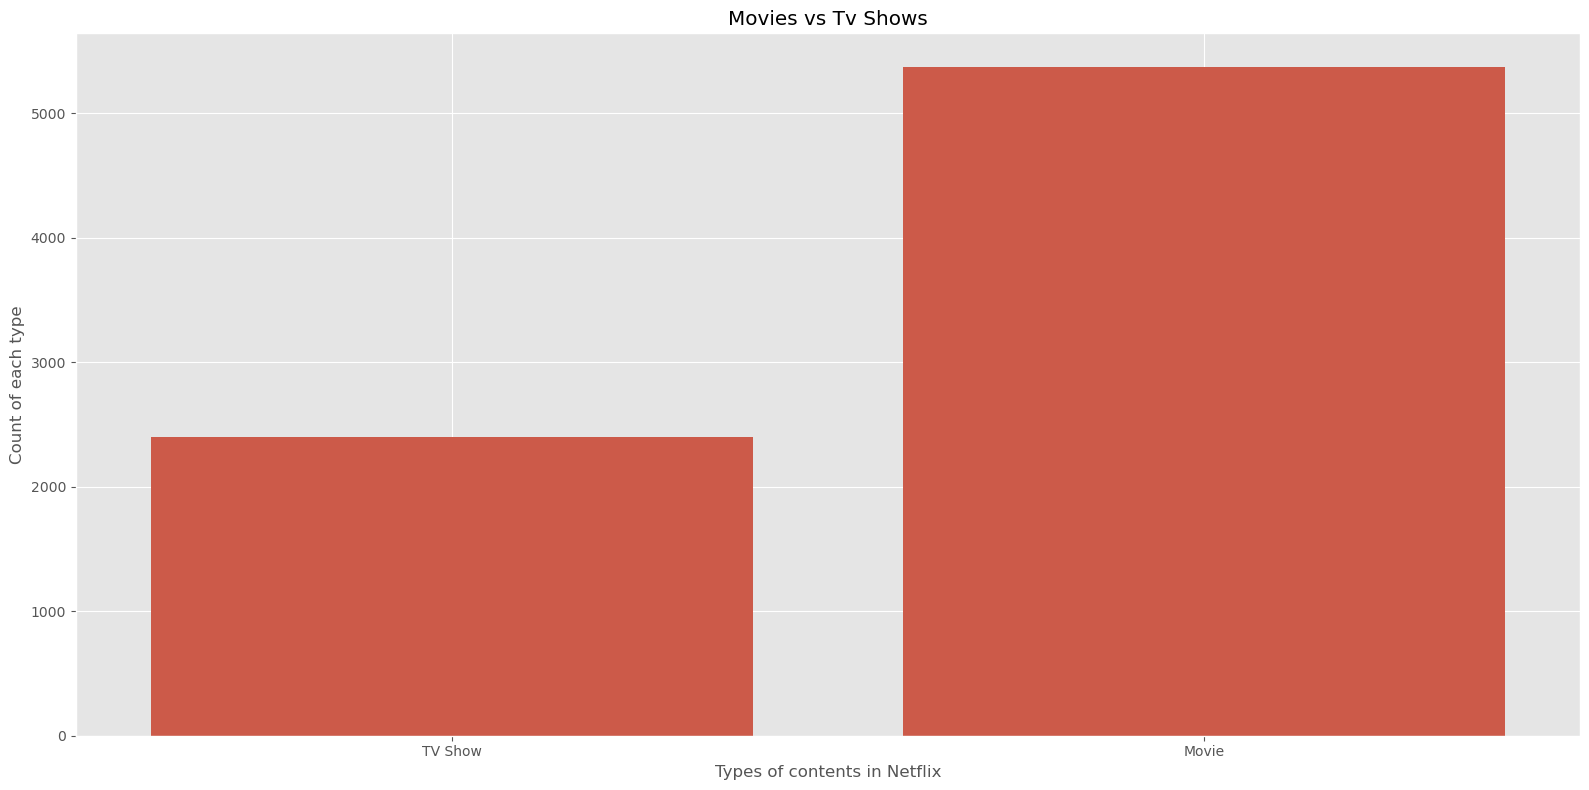

In [78]:
plt.style.use("ggplot")

plt.figure(figsize=(16, 8))

sns.countplot(x="type", data=df)

plt.title("Movies vs Tv Shows")
plt.xlabel("Types of contents in Netflix")
plt.ylabel("Count of each type")
plt.grid(True)
plt.tight_layout()
plt.show()

📌 From the above plot we can see that movie is dominating over Netflix.

## ❓ Most common ratings

In [79]:
unique_values = df["rating"].value_counts().head(6)

print(unique_values)

rating
TV-MA    2861
TV-14    1928
TV-PG     804
R         665
PG-13     386
TV-Y      279
Name: count, dtype: int64


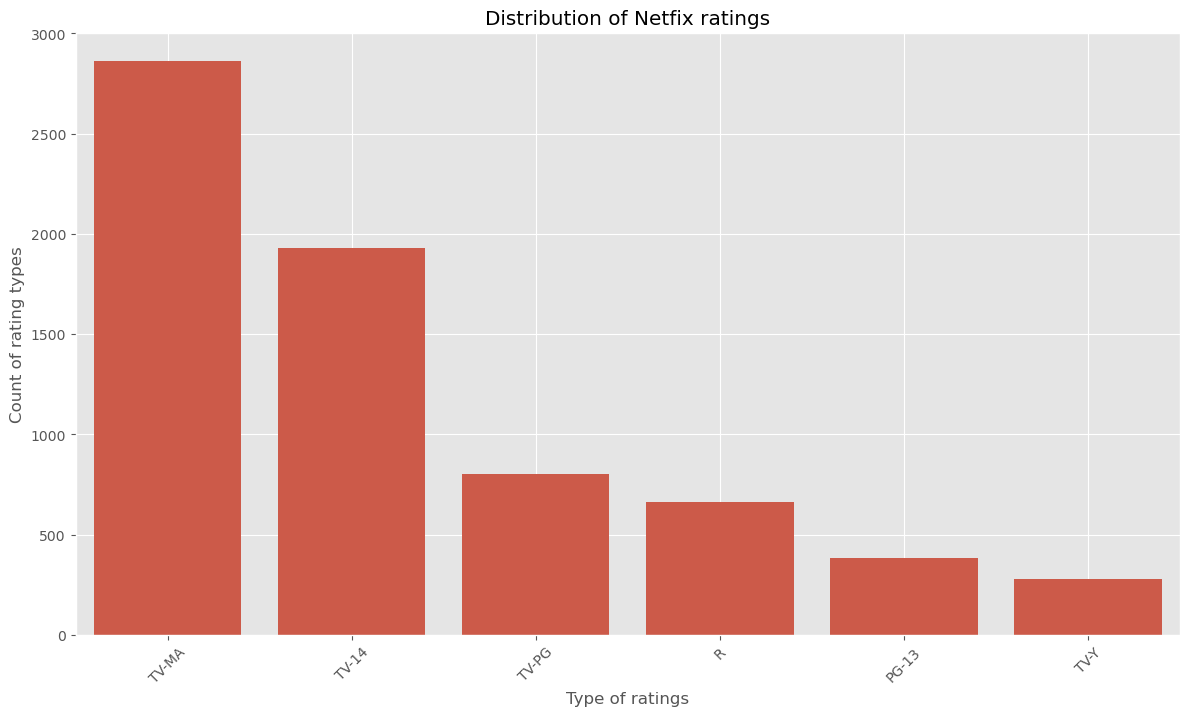

In [80]:
plt.figure(figsize=(12,7))

sns.barplot(x=unique_values.index, y=unique_values.values)
plt.title("Distribution of Netfix ratings")
plt.xlabel("Type of ratings")
plt.ylabel("Count of rating types")
plt.tight_layout()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

📌 From the above plot we can see TV-MA, TV-14, and TV-PG ratings dominating the platform’s catalog.

## ❓ Which countries produce the most Netflix content?

In [81]:
df["country"] = df["country"].astype(str).str.split(",")

new_exploded_df = df.explode("country", ignore_index=True)

new_exploded_df = new_exploded_df[new_exploded_df["country"] != "Unknown"]

new_exploded_df["country"] = new_exploded_df["country"].str.strip()

title_per_country = new_exploded_df["country"].value_counts().head(10)

print(title_per_country)

country
United States     3288
India              990
United Kingdom     722
Canada             412
France             349
Japan              285
Spain              215
South Korea        212
Germany            199
Mexico             154
Name: count, dtype: int64


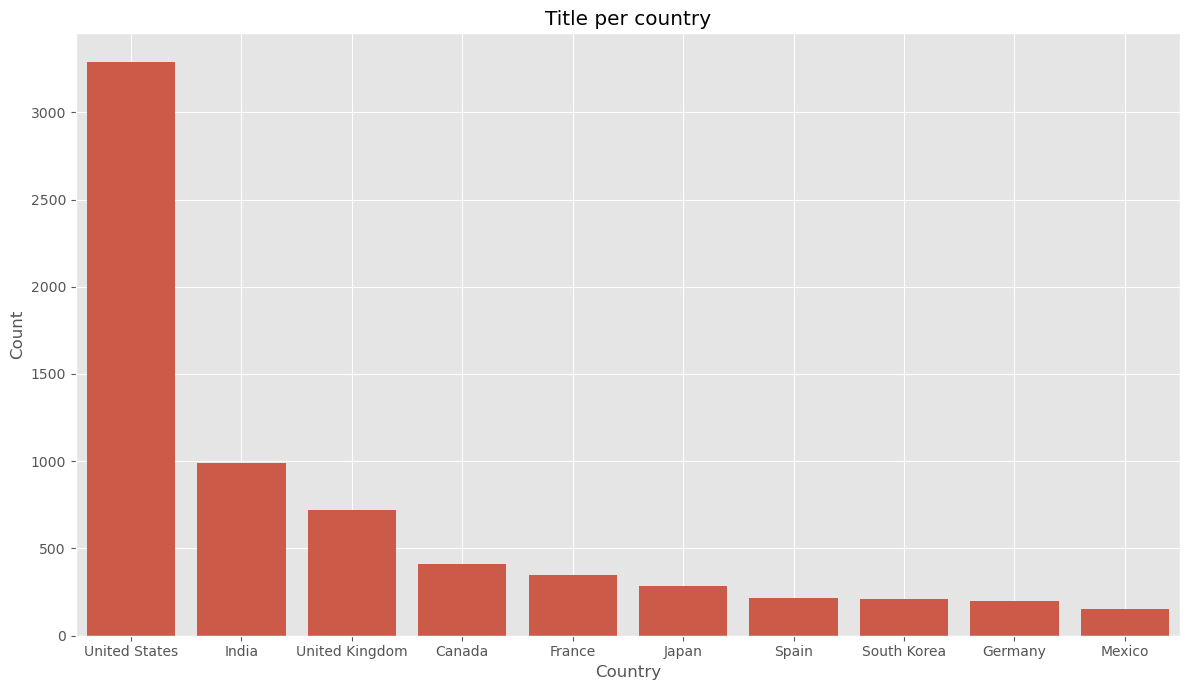

In [82]:
plt.figure(figsize=(12,7))
sns.barplot(x=title_per_country.index, y=title_per_country.values)
plt.title("Title per country")
plt.xlabel("Country")
plt.ylabel("Count")
plt.tight_layout()
plt.grid(True)
plt.show()

📌 The United States is the largest contributor to Netflix’s content library, followed by India and the United Kingdom.

## ❓ Which directors have the highest number of titles on Netflix?

In [83]:
df["director"] = df["director"].astype(str).str.split(", ")

new_director_exploded_df = df.explode("director", ignore_index=True)

new_director_exploded_df = new_director_exploded_df[new_director_exploded_df["director"] != "Unknown"]

print(new_director_exploded_df["director"].value_counts().shape)

top_directors = new_director_exploded_df["director"].value_counts().head(10)

(4476,)


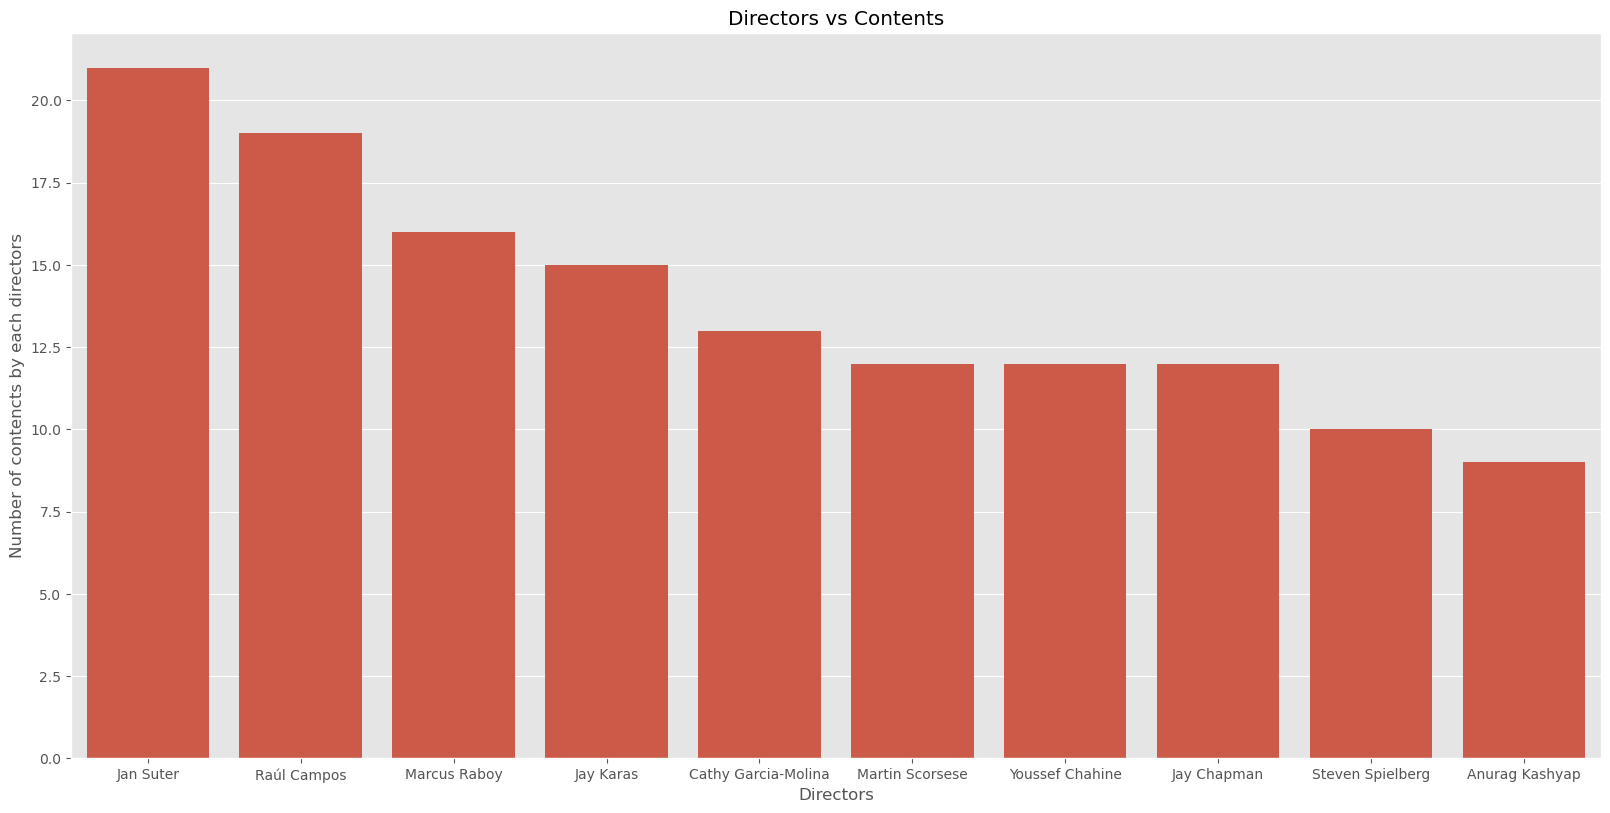

In [84]:
plt.figure(figsize=(16,8))
sns.barplot(x=top_directors.index, y=top_directors.values)
plt.tight_layout()
plt.xlabel("Directors")
plt.ylabel("Number of contencts by each directors")
plt.title("Directors vs Contents")
plt.show()

📌 No single director overwhelmingly dominates Netflix’s content library.

## ❓ In which months does Netflix add the most content?

In [85]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

unique_values_for_month = df["month_added"].value_counts().reindex(month_order)

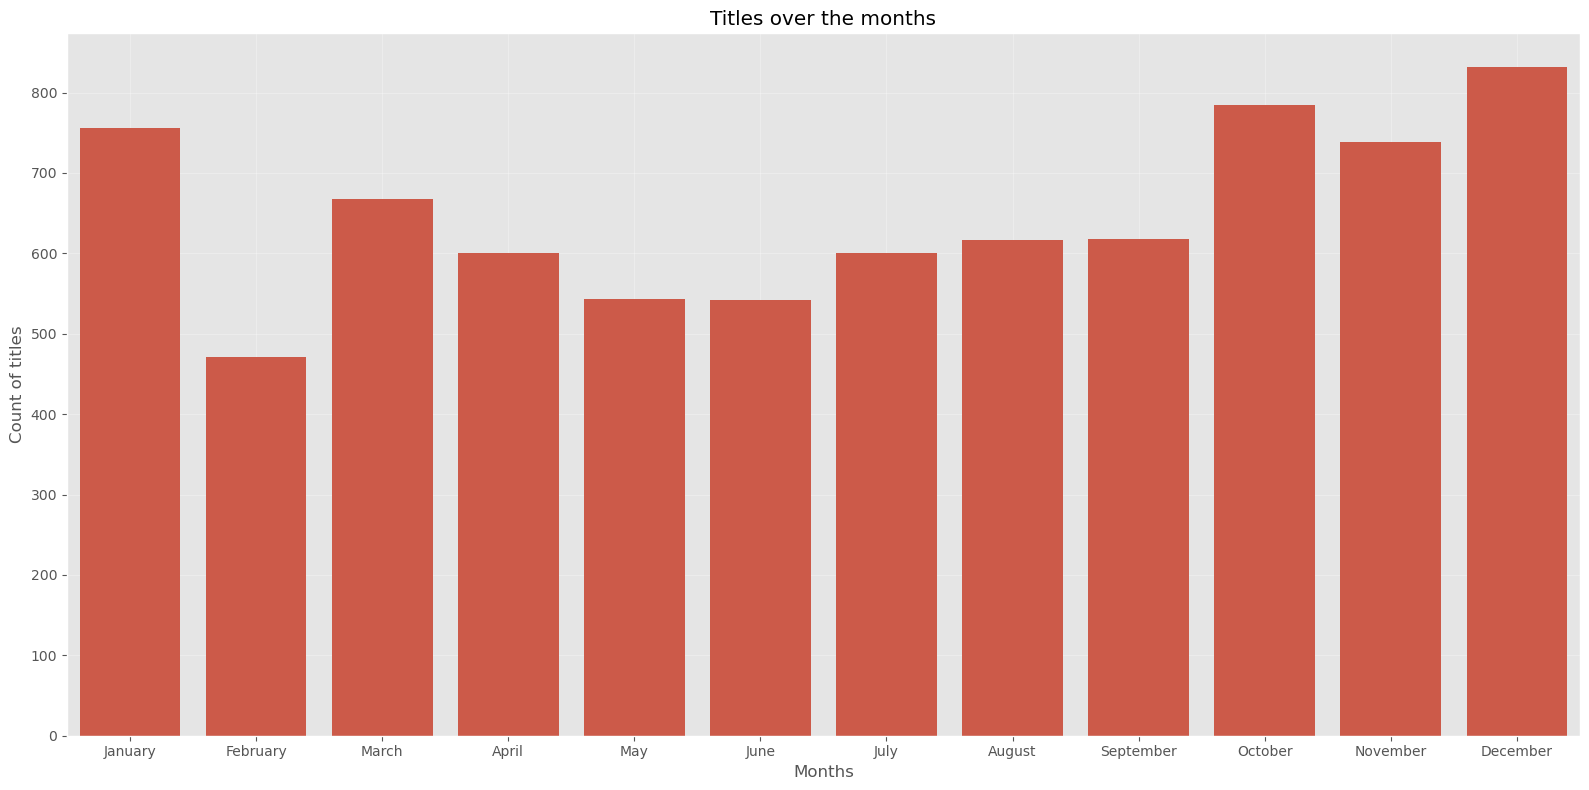

In [86]:
plt.figure(figsize=(16,8))

sns.barplot(x=unique_values_for_month.index, y=unique_values_for_month.values)

plt.grid(True, alpha=0.3)
plt.title("Titles over the months")
plt.xlabel("Months")
plt.ylabel("Count of titles")
plt.tight_layout()
plt.show()

📌 Higher additions during the year end and year starting period.

## ❓ How has Netflix’s content library grown over time (year-wise)?

In [87]:
unique_value_for_year = df["year_added"].value_counts().sort_index()

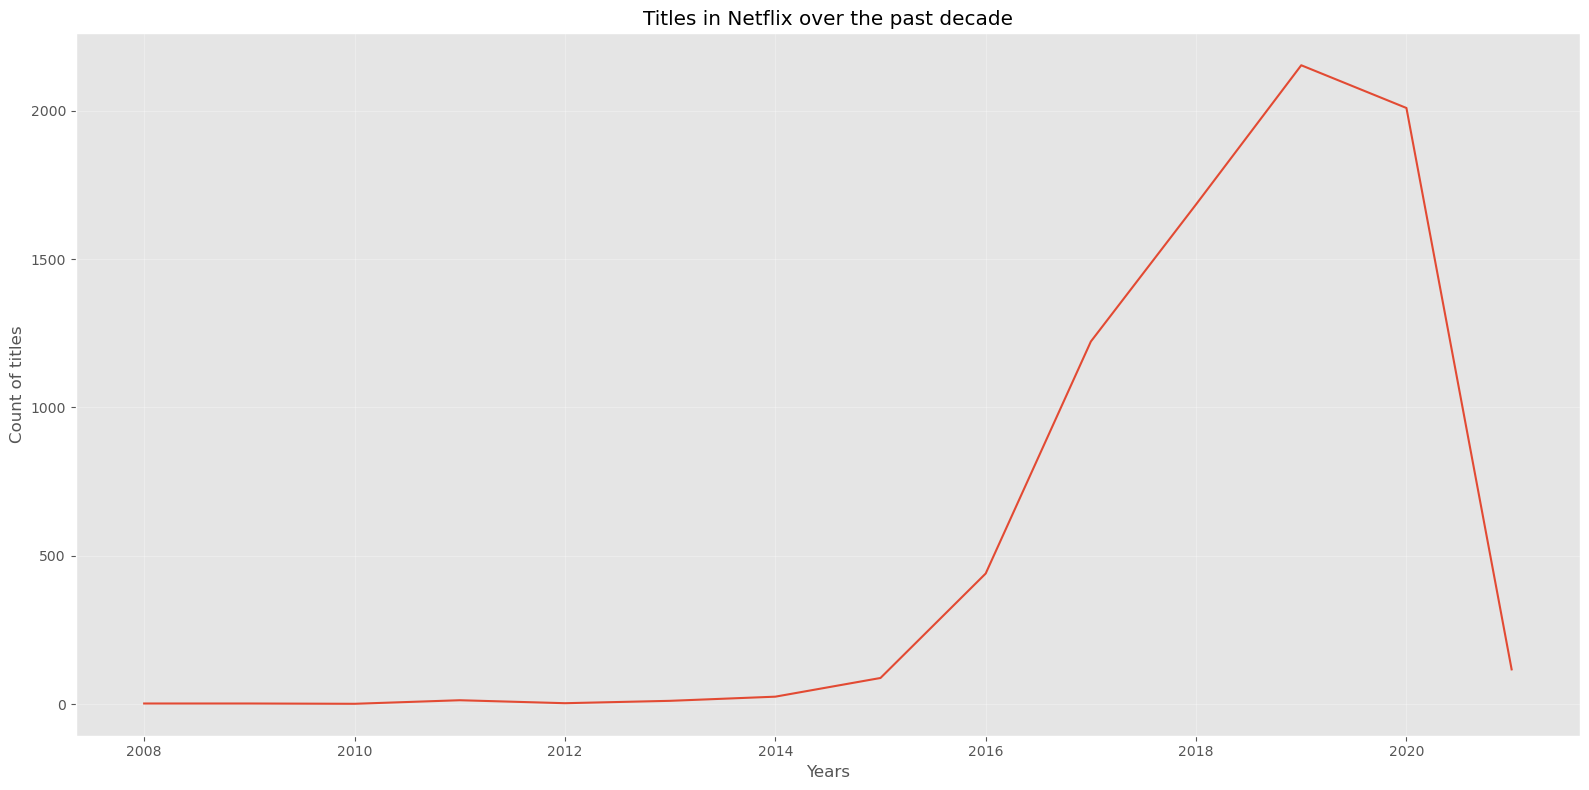

In [88]:

plt.figure(figsize=(16,8))

sns.lineplot(x=unique_value_for_year.index, y=unique_value_for_year.values)
plt.title("Titles in Netflix over the past decade")
plt.xlabel("Years")
plt.ylabel("Count of titles")
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

📌 The highest number of titles were added around 2019

## ❓ What are the most popular genres on Netflix, and how do they differ between Movies and TV Shows?

In [89]:
df["listed_in"] = df["listed_in"].astype(str).str.strip()

df["listed_in"] = df["listed_in"].str.split(", ")

new_exploded_listed_in_df = df.explode("listed_in", ignore_index=True)

genre_count = new_exploded_listed_in_df.groupby("type")["listed_in"].value_counts().reset_index(name="count")

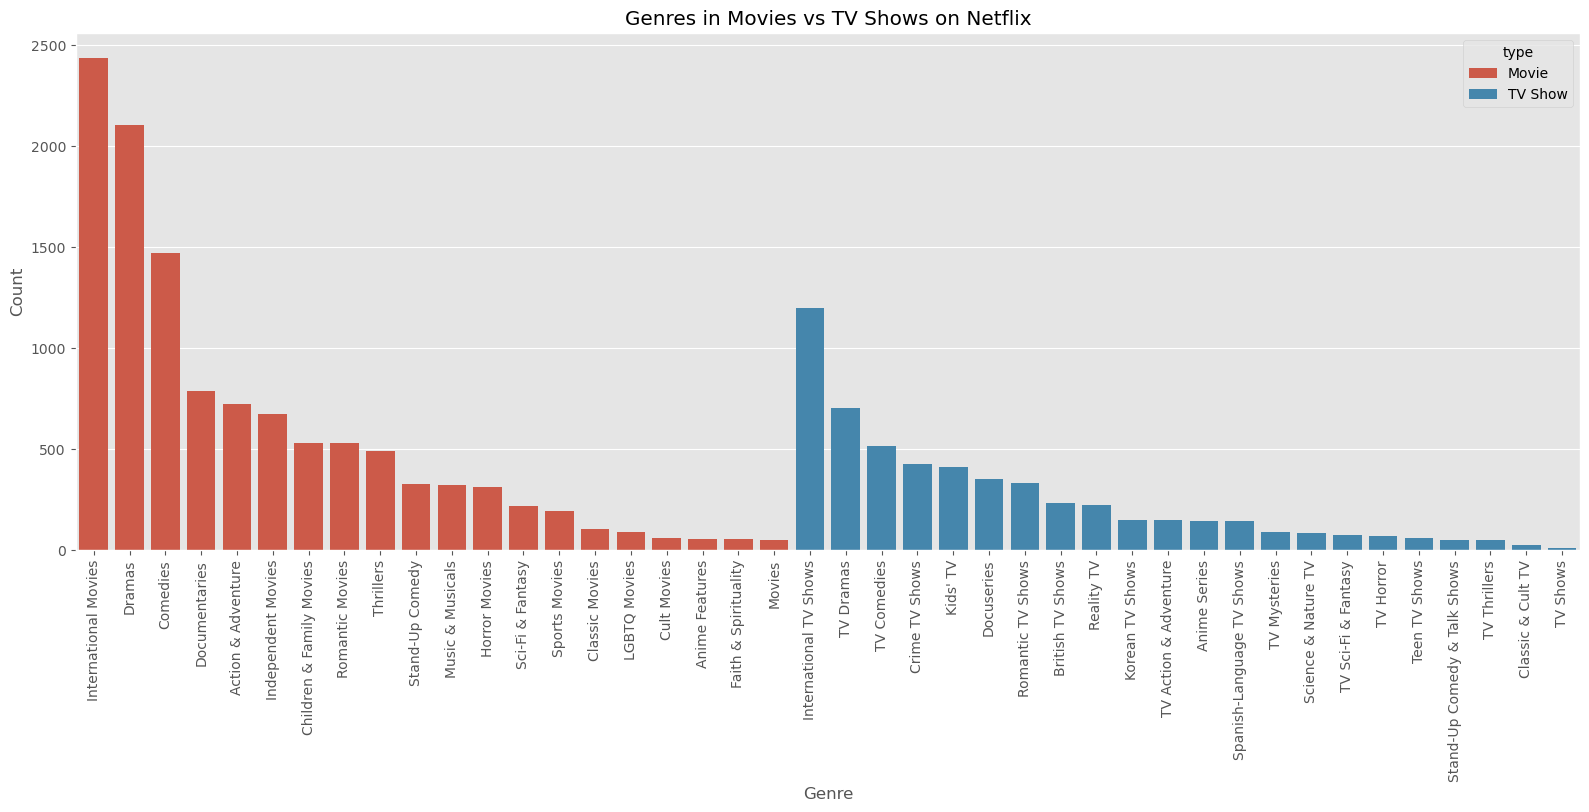

In [90]:

plt.figure(figsize=(16,8))

plt.xticks(rotation=90)
sns.barplot(x="listed_in", y="count", hue="type", data=genre_count)
plt.tight_layout()
plt.xlabel("Genre")
plt.ylabel("Count")
plt.title("Genres in Movies vs TV Shows on Netflix")
plt.show()



📌 Netflix’s content library is heavily dominated by Movies, particularly in genres such as International Movies, Dramas, and Comedies.

## ❓ What is the average duration of Movies on Netflix?

In [91]:
df["duration_num"] = df["duration_num"].astype(str).str.strip().astype(int)

movie_duration = df.loc[df["type"] == "Movie", "duration_num"]

print(movie_duration.mean())

99.33041697691735


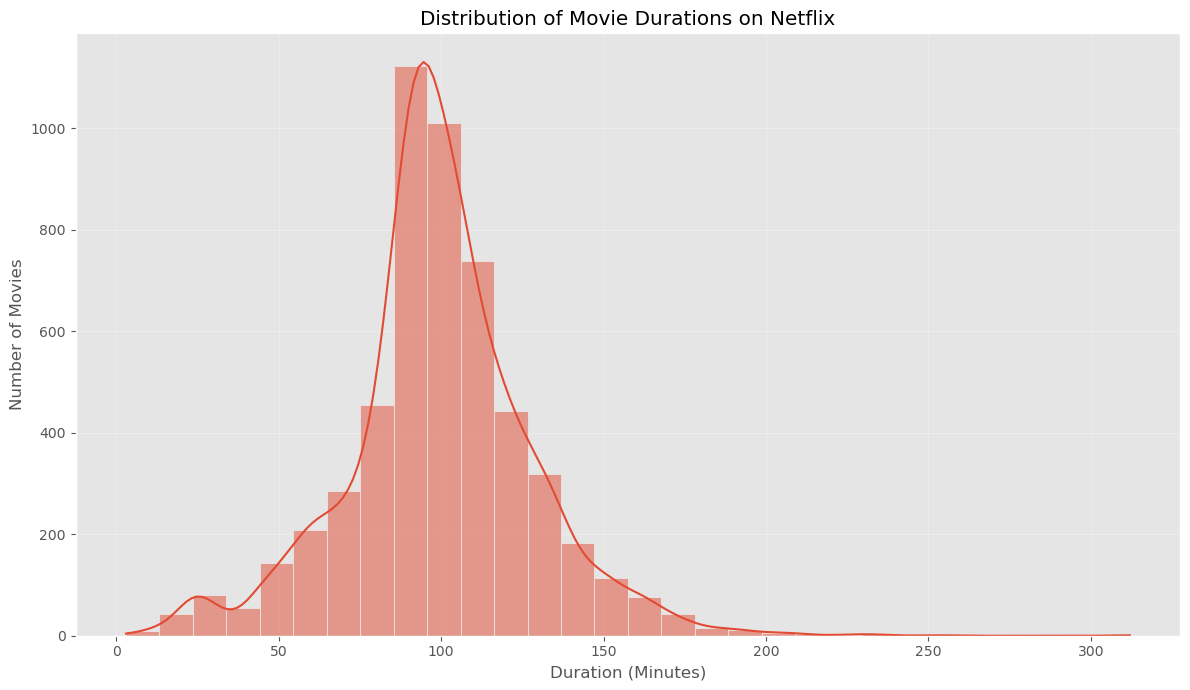

In [92]:
plt.figure(figsize=(12,7))

sns.histplot(movie_duration, bins=30, kde=True)

plt.title("Distribution of Movie Durations on Netflix")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

📌 The average duration of the Movies in Netflix is 99 min which almost 1 hour 40 mins.

## 🔍 Key Insights 
1. Movies Dominate Netflix’s Content Library

Movies represent a significantly larger portion of Netflix’s catalog compared to TV Shows, indicating a historical preference for standalone content over episodic formats. This suggests potential opportunity to further expand serialized content to improve user retention.

2. Platform Primarily Targets Mature and Teen Audiences

The most common content ratings (TV-MA, TV-14, TV-PG) indicate that Netflix primarily caters to mature, teenage, and family audiences, aligning with global streaming consumption patterns.

3. Strong Dependence on Major Content-Producing Countries

The United States leads content production, followed by India and the United Kingdom, highlighting Netflix’s reliance on established entertainment hubs while steadily expanding global content diversity.

4. Diversified Creator Ecosystem

No single director dominates the platform’s catalog, indicating a well-distributed creator network that reduces dependency risk and encourages diverse storytelling.

5. Seasonal Trends in Content Addition

Content additions peak during year-end and early-year months, suggesting a strategic alignment with holiday seasons and peak viewing periods to maximize engagement.

6. Peak Growth Around 2019 Followed by Stabilization

Netflix experienced rapid content expansion leading up to 2019, after which growth stabilized, reflecting a transition from aggressive scaling to content optimization.

7. Strong Preference for High-Demand Genres

Genres such as Dramas, Comedies, and International content dominate the platform, indicating consistent audience demand for broadly appealing entertainment categories.

8. Standard Feature-Length Movies Align with Viewer Behavior

Most movies align with standard feature-length duration, suggesting Netflix optimizes content length for mainstream viewer attention spans and completion rates.

## 🎯 Business Recommendations
1. Balance Movie Dominance with High-Retention TV Content

Movies dominate the catalog, but long-form series typically drive higher engagement and retention. Increasing investment in serialized content can improve subscriber stickiness.

2. Strengthen Regional Content Strategy

Strong contribution from markets like India and the UK highlights the importance of localized storytelling. Expanding regional originals can improve global penetration and user engagement.

3. Prioritize High-Performing Genres

Genres such as Drama, Comedy, and International content show strong presence in the dataset. Focusing on these while selectively testing niche categories can optimize content performance.

4. Align Releases with Seasonal Demand

Content additions appear stronger in specific months (e.g., year-end periods). Aligning major releases with high-engagement seasons can improve viewership impact.

5. Maintain Diverse Creator Ecosystem

The dataset indicates no over-reliance on specific directors, which reduces content risk. Continuing this diversified collaboration model ensures creative variety and stability.

6. Optimize Content Duration Strategy

Mid-length content (approx. 90–120 minutes) aligns well with consumption patterns. Expanding this segment across films and documentaries can improve viewer completion rates.

## 🏁 Conclusion

This project analyzed Netflix’s content library to understand its structure, trends, and business patterns. The analysis revealed a strong focus on movies, mature audience content, and major contributions from key global markets like the US, India, and the UK. Seasonal release patterns and genre preferences also highlight Netflix’s strategic content planning approach.

Overall, this project demonstrates how data analysis can uncover meaningful insights that support better content and business decisions.